In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Matplotlib style
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set(style="whitegrid")

print("[OK] Libraries imported.")

# ------------------------------------------------------------
# 1. 경로 설정
# ------------------------------------------------------------
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    BASE_DIR = os.path.dirname(cwd)
else:
    BASE_DIR = cwd

# 입력 파일 (새로운 100k 전처리 데이터)
INPUT_NPZ = os.path.join(
    BASE_DIR, "data", "processed", "colored_mnist", "colored_mnist_100k_train_val.npz"
)

# 출력 파일 (PCA 적용된 데이터)
OUT_DIR = os.path.join(BASE_DIR, "data", "processed", "colored_mnist")
OUT_NPZ = os.path.join(OUT_DIR, "colored_mnist_100k_pca.npz")

print(f"[INFO] INPUT_NPZ : {INPUT_NPZ}")
print(f"[INFO] OUT_NPZ   : {OUT_NPZ}")

if not os.path.exists(INPUT_NPZ):
    raise FileNotFoundError(f"[ERROR] Input file not found: {INPUT_NPZ}")

# ------------------------------------------------------------
# 2. 데이터 로드
# ------------------------------------------------------------
data = np.load(INPUT_NPZ)
print("[OK] Loaded keys:", list(data.keys()))

# Features (Flattened 2352)
X_train_raw = data["X_train"].astype(np.float32)
X_val_raw   = data["X_val"].astype(np.float32)

# Labels (그대로 복사해서 저장하기 위해 로드)
y_digit_train = data["y_digit_train"]
y_digit_val   = data["y_digit_val"]
y_fg_train    = data["y_fg_train"]
y_fg_val      = data["y_fg_val"]
y_bg_train    = data["y_bg_train"]
y_bg_val      = data["y_bg_val"]
source_train  = data["source_train"]
source_val    = data["source_val"]

print(f"[INFO] X_train shape: {X_train_raw.shape}")
print(f"[INFO] X_val shape  : {X_val_raw.shape}")

[OK] Libraries imported.
[INFO] INPUT_NPZ : c:\src\colored-mnist-classification\data\processed\colored_mnist\colored_mnist_100k_train_val.npz
[INFO] OUT_NPZ   : c:\src\colored-mnist-classification\data\processed\colored_mnist\colored_mnist_100k_pca.npz
[OK] Loaded keys: ['X_train', 'X_val', 'y_digit_train', 'y_digit_val', 'y_fg_train', 'y_fg_val', 'y_bg_train', 'y_bg_val', 'source_train', 'source_val', 'color_palette', 'random_seed', 'deskew_aug_target', 'font_aug_target', 'geom_aug_target']
[INFO] X_train shape: (80000, 2352)
[INFO] X_val shape  : (20000, 2352)


In [6]:
# ------------------------------------------------------------
# 3. 스케일링 (StandardScaler)
# ------------------------------------------------------------
print("[INFO] Applying StandardScaler...")

scaler = StandardScaler()
# Train 데이터로 fit 하고, Train/Val 모두 transform
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)

print("[OK] Standardization completed.")
print(f"  Train Mean (approx 0): {X_train_scaled.mean():.4f}")
print(f"  Train Std  (approx 1): {X_train_scaled.std():.4f}")

[INFO] Applying StandardScaler...
[OK] Standardization completed.
  Train Mean (approx 0): -0.0000
  Train Std  (approx 1): 1.0000


[INFO] Fitting PCA (keeping 95% variance)...
[OK] PCA Finished.
  Original features : 2352
  Reduced features  : 303
  Explained variance: 0.9900
  X_train_pca shape : (80000, 303)
  X_val_pca shape   : (20000, 303)


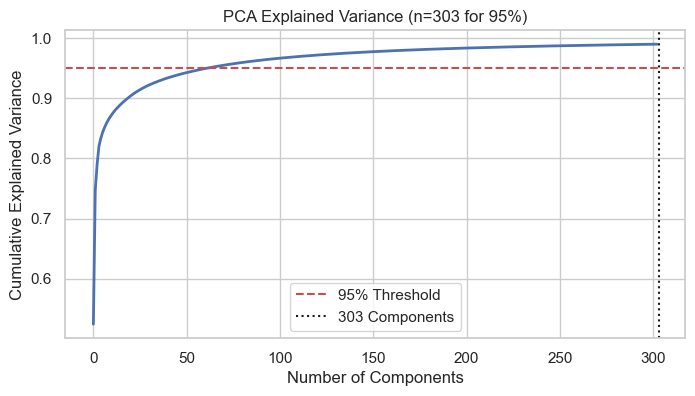

In [7]:
# ------------------------------------------------------------
# 4. PCA 적용 (n_components=0.95)
# ------------------------------------------------------------
print("[INFO] Fitting PCA (keeping 95% variance)...")

# 95% 분산을 유지하도록 주성분 개수 자동 결정
pca = PCA(n_components=0.99, random_state=SEED)

# Train 데이터로 학습
pca.fit(X_train_scaled)

# 변환 (Transform)
X_train_pca = pca.transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)

n_components = pca.n_components_
explained_var = np.sum(pca.explained_variance_ratio_)

print(f"[OK] PCA Finished.")
print(f"  Original features : {X_train_raw.shape[1]}")
print(f"  Reduced features  : {n_components}")
print(f"  Explained variance: {explained_var:.4f}")
print(f"  X_train_pca shape : {X_train_pca.shape}")
print(f"  X_val_pca shape   : {X_val_pca.shape}")

# ------------------------------------------------------------
# 시각화: 설명된 분산 비율 (Elbow Plot)
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title(f'PCA Explained Variance (n={n_components} for 95%)')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components, color='k', linestyle=':', label=f'{n_components} Components')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# ------------------------------------------------------------
# 5. 저장 (PCA된 데이터 + 기존 레이블)
# ------------------------------------------------------------
print(f"[INFO] Saving to {OUT_NPZ} ...")

np.savez_compressed(
    OUT_NPZ,
    # PCA Features
    X_train=X_train_pca.astype(np.float32),
    X_val=X_val_pca.astype(np.float32),
    
    # Labels (Pass-through)
    y_digit_train=y_digit_train,
    y_digit_val=y_digit_val,
    y_fg_train=y_fg_train,
    y_fg_val=y_fg_val,
    y_bg_train=y_bg_train,
    y_bg_val=y_bg_val,
    
    # Metadata
    source_train=source_train,
    source_val=source_val,
    pca_components=n_components,
    explained_variance=explained_var
)

print("[DONE] File saved successfully.")

[INFO] Saving to c:\src\colored-mnist-classification\data\processed\colored_mnist\colored_mnist_100k_pca.npz ...
[DONE] File saved successfully.
